# Fraud Detection System — Machine Learning

**Platform:** Cloudera AI  
**Date:** 6 April 2026  

---

## Objective
Demostrating Cloudera Platform's MLOps Capabilities using transactional data.

## Key Highlights
| Capability | Details |
|---|---|
| **Class Imbalance Handling** | SMOTE oversampling + class weights |
| **Feature Engineering** | Velocity, behavioural, and temporal signals |
| **Model Explainability** | SHAP values for regulatory compliance |
| **Model Tracking & Versioning** | MLflow on Cloudera ML |
| **Deployment Pipeline** | Auto-push to CML Model Registry → GitHub → Serving Endpoint |

> **How this works end-to-end:** Data scientists train and evaluate models in this notebook. Once satisfied, a single call registers the model to **MLflow Model Registry**, which triggers a **CI/CD pipeline via GitHub Actions** to automatically deploy the model as a live REST API endpoint — no manual hand-off required.


---
## Step 1: Environment Setup
All dependencies are pre-installed in the **Cloudera ML Runtime**. We simply import and configure.

In [2]:
import os, warnings, sys, logging
import mlflow
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score
import mlflow.sklearn
from xgboost import XGBClassifier
from datetime import date
import cml.data_v1 as cmldata
import pyspark.pandas as ps
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

# ── Standard Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── ML & Feature Engineering ─────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE

# ── Explainability ────────────────────────────────────────────────────────────
import shap

# ── Cloudera ML — MLflow Tracking ─────────────────────────────────────────────
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# ── Cloudera ML Environment Config ───────────────────────────────────────────
import os
import json
import joblib

os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"
ARTIFACT_PATH     = "./artifacts"
EXPERIMENT_NAME = 'fraud-xgboost-exp'
MODEL_NAME        = "fraud-detection-xgb"
GITHUB_REPO = 'https://github.com/prampradeep/Fraud_Detection.git'


---
## Step 2: Load Transactional Data
Loading Data directly from Data Lake, using native security applied at the data lake layer

In [7]:
import cml.data_v1 as cmldata

CONNECTION_NAME = "default-hive-aws"
conn = cmldata.get_connection(CONNECTION_NAME)

## Sample Usage to get pandas data frame
EXAMPLE_SQL_QUERY = "select * from frauddb.fraud_txn_details"
df = conn.get_pandas_dataframe(EXAMPLE_SQL_QUERY)
df.columns = [c.split('.')[-1] for c in df.columns]
# Closing the connection
conn.close()
print(f"Dataset shape     : {df.shape}")
print(f"Fraud rate        : {df['is_fraud'].mean()*100:.2f}%")
print(f"Fraud transactions: {df['is_fraud'].sum():,}")
df.head()
training_table = 'frauddb.fraud_txn_details'

Dataset shape     : (50000, 13)
Fraud rate        : 1.50%
Fraud transactions: 750


---
## Step 3: Exploratory Data Analysis

Building some charts around Class distribution, Transaction amount distribution , Fraud by hour of day, Distance from home , Transaction count in 24h etc.

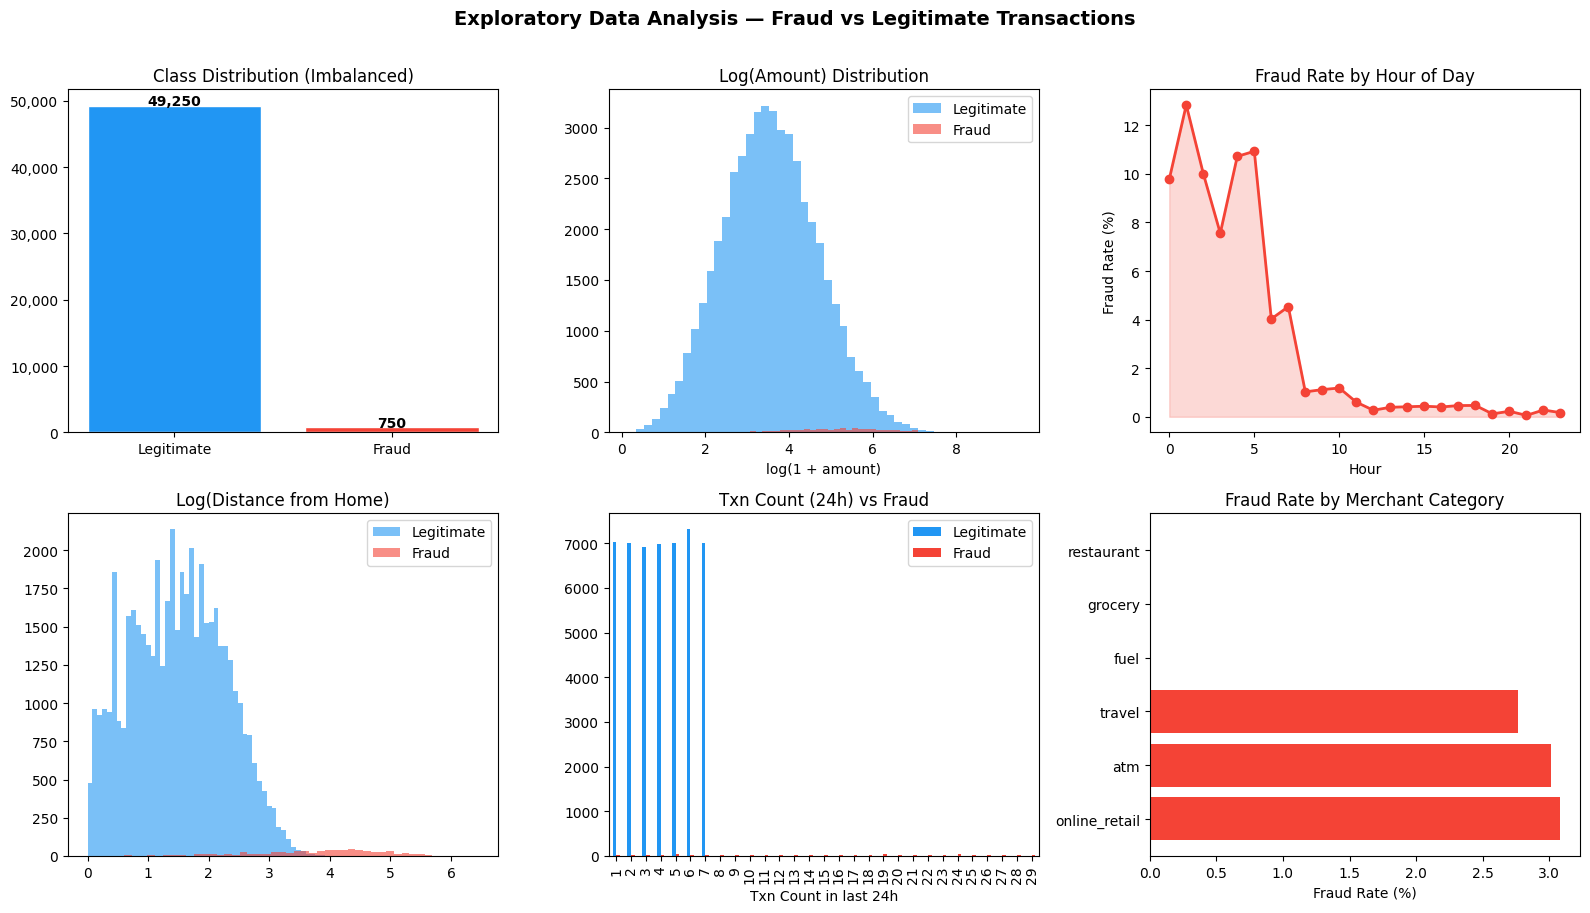

📊 EDA complete. Plot saved to artifacts/


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Exploratory Data Analysis — Fraud vs Legitimate Transactions",
             fontsize=14, fontweight='bold', y=1.01)

palette = {0: '#2196F3', 1: '#F44336'}
labels  = {0: 'Legitimate', 1: 'Fraud'}

#Creating Artifact Directoty 
os.makedirs(ARTIFACT_PATH, exist_ok=True)

# 1. Class distribution
ax = axes[0, 0]
counts = df['is_fraud'].value_counts()
bars = ax.bar([labels[i] for i in counts.index],
              counts.values,
              color=[palette[i] for i in counts.index], edgecolor='white')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Class Distribution (Imbalanced)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 2. Transaction amount distribution
ax = axes[0, 1]
for label, grp in df.groupby('is_fraud'):
    ax.hist(np.log1p(grp['amount']), bins=50, alpha=0.6,
            label=labels[label], color=palette[label])
ax.set_title('Log(Amount) Distribution')
ax.set_xlabel('log(1 + amount)')
ax.legend()

# 3. Fraud by hour of day
ax = axes[0, 2]
fraud_by_hour = df.groupby('hour_of_day')['is_fraud'].mean() * 100
ax.plot(fraud_by_hour.index, fraud_by_hour.values, color='#F44336', marker='o', linewidth=2)
ax.fill_between(fraud_by_hour.index, fraud_by_hour.values, alpha=0.2, color='#F44336')
ax.set_title('Fraud Rate by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Fraud Rate (%)')

# 4. Distance from home
ax = axes[1, 0]
for label, grp in df.groupby('is_fraud'):
    ax.hist(np.log1p(grp['distance_from_home']), bins=50, alpha=0.6,
            label=labels[label], color=palette[label])
ax.set_title('Log(Distance from Home)')
ax.legend()

# 5. Transaction count in 24h
ax = axes[1, 1]
df.groupby(['txn_count_24h', 'is_fraud']).size().unstack(fill_value=0).plot(
    kind='bar', ax=ax, color=[palette[0], palette[1]], legend=True)
ax.set_title('Txn Count (24h) vs Fraud')
ax.set_xlabel('Txn Count in last 24h')
ax.legend([labels[0], labels[1]])

# 6. Merchant category fraud rate
ax = axes[1, 2]
cat_fraud = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False) * 100
ax.barh(cat_fraud.index, cat_fraud.values,
        color=['#F44336' if v > 2 else '#2196F3' for v in cat_fraud.values])
ax.set_title('Fraud Rate by Merchant Category')
ax.set_xlabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig(f'{ARTIFACT_PATH}/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 EDA complete. Plot saved to artifacts/")

---
## Step 4: Feature Engineering
We engineer domain-driven financial signals that help the model detect anomalous behaviour patterns.

In [5]:
def engineer_features(df):
    d = df.copy()

    # ── Velocity signals ──────────────────────────────────────────────────────
    d['amount_vs_avg_ratio']   = d['amount'] / (d['avg_amount_30d'] + 1e-6)
    d['high_velocity_flag']    = (d['txn_count_24h'] > 5).astype(int)

    # ── Behavioural anomaly signals ────────────────────────────────────────────
    d['distance_log']          = np.log1p(d['distance_from_home'])
    d['amount_log']            = np.log1p(d['amount'])
    d['far_from_home']         = (d['distance_from_home'] > 50).astype(int)
    d['large_amount_flag']     = (d['amount'] > d['amount'].quantile(0.95)).astype(int)

    # ── Temporal signals ───────────────────────────────────────────────────────
    d['is_night']              = ((d['hour_of_day'] >= 22) | (d['hour_of_day'] <= 5)).astype(int)
    d['is_weekend']            = (d['day_of_week'] >= 5).astype(int)

    # ── Risk composite score ───────────────────────────────────────────────────
    d['risk_score'] = (
        d['is_international']  * 2 +
        d['device_change']     * 2 +
        d['failed_attempts_24h'] +
        d['far_from_home']     +
        d['is_night']          +
        d['high_velocity_flag']
    )

    # ── Merchant one-hot encoding ──────────────────────────────────────────────
    d = pd.get_dummies(d, columns=['merchant_category'], drop_first=False)

    return d

df_fe = engineer_features(df)

DROP_COLS = ['transaction_id', 'is_fraud']
FEATURE_COLS = [c for c in df_fe.columns if c not in DROP_COLS]
TARGET = 'is_fraud'

print(f"Features engineered: {len(FEATURE_COLS)} total")
print("   New features added:")
new_feats = ['amount_vs_avg_ratio','high_velocity_flag','distance_log','amount_log',
             'far_from_home','large_amount_flag','is_night','is_weekend','risk_score']
for f in new_feats:
    print(f"   • {f}")

Features engineered: 25 total
   New features added:
   • amount_vs_avg_ratio
   • high_velocity_flag
   • distance_log
   • amount_log
   • far_from_home
   • large_amount_flag
   • is_night
   • is_weekend
   • risk_score


---
## Step 5: Handle Class Imbalance with SMOTE
Fraud is rare (~1.5%). Without correction, models learn to ignore fraud entirely. We use **SMOTE** (Synthetic Minority Oversampling Technique) to create balanced training data.

In [6]:
X = df_fe[FEATURE_COLS].astype(float)
y = df_fe[TARGET]
test_size=0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Before SMOTE:")
print(f"  Train fraud rate : {y_train.mean()*100:.2f}%  ({y_train.sum():,} fraud / {len(y_train):,} total)")

smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Train fraud rate : {y_train_bal.mean()*100:.2f}%  ({y_train_bal.sum():,} fraud / {len(y_train_bal):,} total)")
print(f"\nTest set (untouched): {y_test.sum():,} fraud / {len(y_test):,} total ({y_test.mean()*100:.2f}%)")

Before SMOTE:
  Train fraud rate : 1.50%  (600 fraud / 40,000 total)

After SMOTE:
  Train fraud rate : 23.08%  (11,820 fraud / 51,220 total)

Test set (untouched): 150 fraud / 10,000 total (1.50%)


---
## Step 6: Model Training with MLflow Tracking
We train a **Extreme Gradient Boosting Classifier (XGBClassifier)** and log everything — parameters, metrics, and artifacts — to **Cloudera's MLflow server**. This creates a full audit trail for compliance and reproducibility.

In [8]:
PARAMS = {
    'n_estimators'   : 300,
    'max_depth'      : 5,
    'learning_rate'  : 0.05,
    'subsample'      : 0.8,
    'min_samples_leaf': 20,
    'random_state'   : 42
}

mlflow.set_experiment(EXPERIMENT_NAME)
def getLatestExperimentInfo(experimentName):
    """
    Method to capture the latest Experiment Id and Run ID for the provided experimentName
    """
    experimentId = mlflow.get_experiment_by_name(experimentName).experiment_id
    runsDf = mlflow.search_runs(experimentId, run_view_type=1)
    experimentId = runsDf.iloc[-1]['experiment_id']
    experimentRunId = runsDf.iloc[-1]['run_id']

    return experimentId, experimentRunId

experimentId, experimentRunId = getLatestExperimentInfo(EXPERIMENT_NAME)
#Replace Experiment Run ID here:
run = mlflow.get_run(experimentRunId)

with mlflow.start_run(run_name="gbm-fraud-detection-run3"):
    RUN_ID = run.info.run_id
    model = XGBClassifier(**PARAMS,use_label_encoder=False, eval_metric="logloss")
    model.fit(X_train_bal, y_train_bal, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Accuracy: %.2f%%" % (accuracy * 100.0))
    print("Test Size: %.2f%%" % (test_size * 100.0))
    
    mlflow.log_params(PARAMS)
    mlflow.log_param("accuracy", accuracy)
    mlflow.log_param("test_size", test_size) 
    mlflow.log_param("training_table", training_table)

    # Step 2:
    # Step 3:
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc  = roc_auc_score(y_test, y_prob)
    pr_auc   = average_precision_score(y_test, y_prob)
    f1       = f1_score(y_test, y_pred)

    mlflow.xgboost.log_model(model, artifact_path="artifacts")#, registered_model_name="my_xgboost_model"
    # ── Save artifacts locally too ────────────────────────────────────────────
    joblib.dump(model,        f'{ARTIFACT_PATH}/fraud_model.pkl')
    joblib.dump(FEATURE_COLS, f'{ARTIFACT_PATH}/feature_cols.pkl')

    with open(f'{ARTIFACT_PATH}/model_metadata.json', 'w') as f:
        json.dump({
            'run_id'      : RUN_ID,
            'model_name'  : MODEL_NAME,
            'roc_auc'     : round(roc_auc, 4),
            'pr_auc'      : round(pr_auc, 4),
            'f1_score'    : round(f1, 4),
            'github_repo' : GITHUB_REPO,
            'features'    : FEATURE_COLS
        }, f, indent=2)

    mlflow.log_artifact(f'{ARTIFACT_PATH}/model_metadata.json')
    
print(f"\nTraining complete!")
print(f"   ROC-AUC  : {roc_auc:.4f}")
print(f"   PR-AUC   : {pr_auc:.4f}")
print(f"   F1 Score : {f1:.4f}")
print(f"\nModel registered in MLflow as: '{MODEL_NAME}'")


pd.DataFrame(data=[run.data.params], index=["Value"]).T
pd.DataFrame(data=[run.data.metrics], index=["Value"]).T

client = mlflow.tracking.MlflowClient()
client.list_artifacts(run_id=run.info.run_id)



Creating run for experiment_id: 4l34-ifli-b0io-njph, user_id: cdsw, run_name: gbm-fraud-detection-run3


Accuracy: 99.94%
Test Size: 20.00%


2026/04/06 06:58:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Training complete!
   ROC-AUC  : 0.9990
   PR-AUC   : 0.9884
   F1 Score : 0.9797

Model registered in MLflow as: 'fraud-detection-xgb'


[<FileInfo: file_size=None, is_dir=True, path='artifacts'>,
 <FileInfo: file_size=834, is_dir=False, path='model_metadata.json'>]

---
## Step 7: Model Performance Evaluation

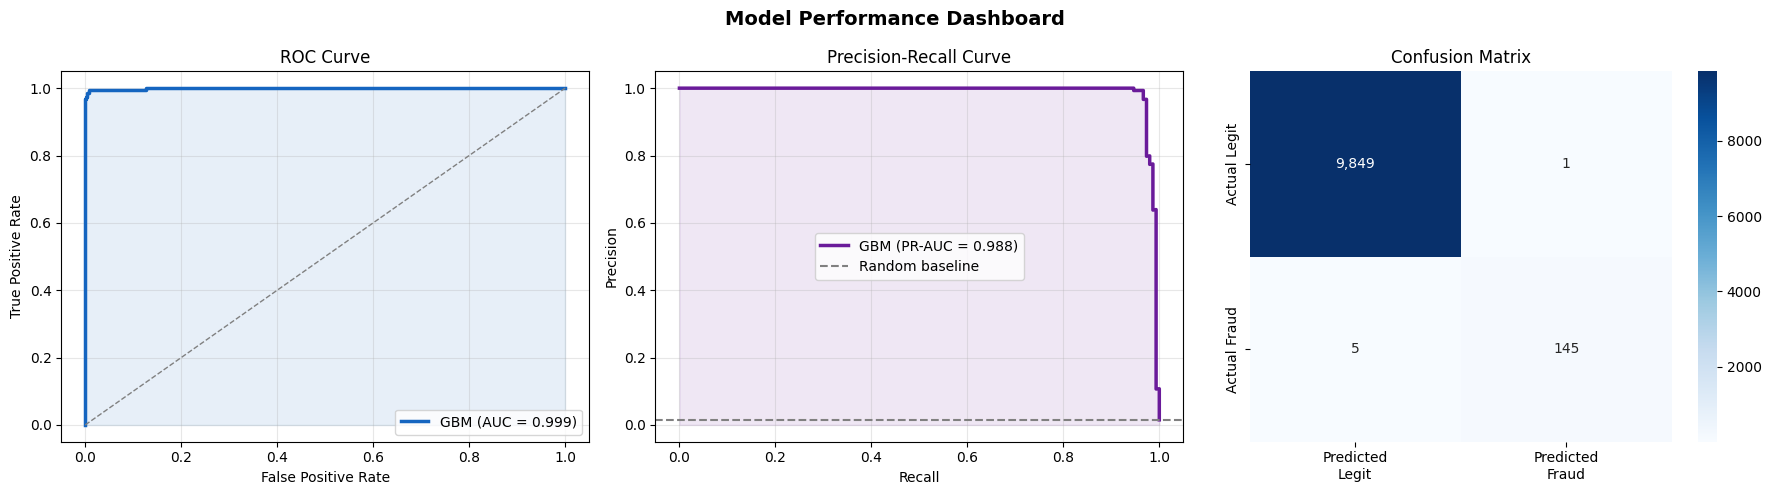


 Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      9850
       Fraud       0.99      0.97      0.98       150

    accuracy                           1.00     10000
   macro avg       1.00      0.98      0.99     10000
weighted avg       1.00      1.00      1.00     10000



In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Performance Dashboard", fontsize=14, fontweight='bold')

# 1. ROC Curve
ax = axes[0]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color='#1565C0', linewidth=2.5, label=f'GBM (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax.fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# 2. Precision-Recall Curve
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ax.plot(rec, prec, color='#6A1B9A', linewidth=2.5, label=f'GBM (PR-AUC = {pr_auc:.3f})')
ax.fill_between(rec, prec, alpha=0.1, color='#6A1B9A')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--', label='Random baseline')
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
ax.grid(alpha=0.3)

# 3. Confusion Matrix
ax = axes[2]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Predicted\nLegit', 'Predicted\nFraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
ax.set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig(f'{ARTIFACT_PATH}/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

## Capturing the Payload 

In [12]:
# 1. Select the row(s) you want to send (e.g., the first row)
# Use double brackets [[]] to keep it as a DataFrame
sample_df = X_train_bal.iloc[[0]] 

# 2. Convert to the 'split' dictionary format
# This creates a dict with 'columns', 'index', and 'data' keys
split_dict = sample_df.to_dict(orient='split')

# 3. Clean up: MLflow/CML usually doesn't want the 'index' key
if 'index' in split_dict:
    del split_dict['index']

# 4. Wrap it for the API (Add your accessKey and the 'request' wrapper)
payload = {
    "accessKey": "your_access_key_here",
    "request": {
        "dataframe_split": split_dict
    }
}

# 5. Convert to a JSON string for the API call
json_payload = json.dumps(payload, indent=2)
print(json_payload)

{
  "accessKey": "your_access_key_here",
  "request": {
    "dataframe_split": {
      "columns": [
        "amount",
        "hour_of_day",
        "day_of_week",
        "distance_from_home",
        "txn_count_24h",
        "avg_amount_30d",
        "is_international",
        "device_change",
        "failed_attempts_24h",
        "account_age_days",
        "amount_vs_avg_ratio",
        "high_velocity_flag",
        "distance_log",
        "amount_log",
        "far_from_home",
        "large_amount_flag",
        "is_night",
        "is_weekend",
        "risk_score",
        "merchant_category_atm",
        "merchant_category_fuel",
        "merchant_category_grocery",
        "merchant_category_online_retail",
        "merchant_category_restaurant",
        "merchant_category_travel"
      ],
      "data": [
        [
          4.89,
          15.0,
          2.0,
          3.7,
          5.0,
          43.11,
          0.0,
          0.0,
          1.0,
          1541.0,
    